# P3b -- HMM Regime Factor Allocation

**Can HMM beat GMM for regime-conditioned factor allocation?**

GMM (P3) classifies each month independently — it doesn't know what regime it was in last month. HMM explicitly models regime transitions: "if we were in expansion, there's a 95% chance we stay in expansion."

This should produce:
- More stable regime labels (fewer whipsaws)
- Lower turnover (fewer unnecessary rebalances)
- Better factor allocation if regime persistence matters

**Same framework as P3:** walk-forward, same data, same factor allocation logic. Only the regime model changes (GMM → HMM).

**Also tests:** regime count sweep (k=2,3,4,5), HMM-specific analysis (transition matrices, regime durations, stationary distribution).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, time, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from hmmlearn import hmm
from itertools import product

DATA_DIR = './data'
RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load factor returns
import pandas_datareader.data as web

ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1963-01-01')
mom = web.DataReader('F-F_Momentum_Factor', 'famafrench', start='1963-01-01')
factors_all = ff5[0].join(mom[0]) / 100
factors_all.index = factors_all.index.to_timestamp()

factor_names = ['SMB', 'HML', 'RMW', 'CMA', 'Mom']
factor_returns = factors_all[factor_names].copy()

# Load macro panel
monthly_macro = pd.read_csv(f'{DATA_DIR}/monthly_panel_transformed.csv', index_col=0, parse_dates=True)
quarterly_macro = pd.read_csv(f'{DATA_DIR}/quarterly_panel_transformed.csv', index_col=0, parse_dates=True)
assert monthly_macro.shape[1] > 0

quarterly_ffill = quarterly_macro.resample('MS').ffill()
macro_panel = pd.concat([monthly_macro, quarterly_ffill], axis=1).ffill().bfill().fillna(0)
macro_panel = macro_panel.dropna(axis=1, how='all')

# Align
common_start = max(macro_panel.index.min(), factor_returns.index.min())
common_end = min(macro_panel.index.max(), factor_returns.index.max())
common_idx = macro_panel[common_start:common_end].index.intersection(
    factor_returns[common_start:common_end].index)
macro_aligned = macro_panel.loc[common_idx]
factors_aligned = factor_returns.loc[common_idx]

print(f'Macro: {macro_aligned.shape}, Factors: {factors_aligned.shape}')
print(f'Range: {common_idx.min()} to {common_idx.max()}')

Macro: (502, 32), Factors: (502, 5)
Range: 1984-04-01 00:00:00 to 2026-01-01 00:00:00


In [2]:
def compute_regime_weights(factor_rets_hist, regime_hist, current_regime, n_factors):
    mask = regime_hist == current_regime
    if mask.sum() < 6:
        return np.ones(n_factors) / n_factors
    regime_avg = factor_rets_hist[mask].mean()
    ranks = regime_avg.rank(ascending=True)
    weights = ranks / ranks.sum()
    weights = np.maximum(weights.values, 0.05)
    return weights / weights.sum()


def run_gmm_strategy(macro_aligned, factors_aligned, factor_names,
                      n_regimes=3, n_pca=5, init_train_pct=0.50,
                      refit_every=12, cov_type='full', tc_bps=0):
    """P3's original GMM strategy — copied exactly."""
    N = len(macro_aligned)
    init_train = int(N * init_train_pct)
    n_factors = len(factor_names)
    tc = tc_bps / 10000

    strat_rets, eq_rets = [], []
    strat_weights, strat_regimes, strat_dates = [], [], []
    prev_w = np.ones(n_factors) / n_factors
    last_refit = -999

    for t in range(init_train, N):
        date = macro_aligned.index[t]
        actual_rets = factors_aligned.iloc[t].values

        if t - last_refit >= refit_every or t == init_train:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(macro_aligned.iloc[:t])
            n_pca_safe = min(n_pca, X_scaled.shape[1], X_scaled.shape[0])
            pca = PCA(n_components=n_pca_safe)
            X_pca = pca.fit_transform(X_scaled)
            gmm = GaussianMixture(n_components=n_regimes, covariance_type=cov_type,
                                   n_init=10, random_state=42)
            gmm.fit(X_pca)
            last_refit = t

        x_now = pca.transform(scaler.transform(macro_aligned.iloc[[t]]))
        regime = gmm.predict(x_now)[0]

        # Reclassify all past with current model
        past_regimes = pd.Series(
            gmm.predict(pca.transform(scaler.transform(macro_aligned.iloc[:t]))),
            index=macro_aligned.index[:t])
        past_factors = factors_aligned.iloc[:t]
        common = past_factors.index.intersection(past_regimes.index)

        w = compute_regime_weights(past_factors.loc[common], past_regimes.loc[common],
                                    regime, n_factors)
        eq_ret = np.mean(actual_rets)
        turnover = np.sum(np.abs(w - prev_w))

        strat_rets.append(np.sum(w * actual_rets) - turnover * tc)
        eq_rets.append(eq_ret)
        strat_weights.append(w)
        strat_regimes.append(regime)
        strat_dates.append(date)
        prev_w = w.copy()

    return {
        'strat_rets': np.array(strat_rets), 'eq_rets': np.array(eq_rets),
        'weights': np.array(strat_weights), 'regimes': np.array(strat_regimes),
        'dates': np.array(strat_dates),
    }


def run_hmm_strategy(macro_aligned, factors_aligned, factor_names,
                      n_regimes=3, n_pca=5, init_train_pct=0.50,
                      refit_every=12, cov_type='full', tc_bps=0):
    """
    HMM regime strategy — same allocation logic as GMM, different regime model.
    
    Key difference: HMM models P(regime_t | regime_t-1), so regime labels
    are informed by the transition structure, not just current features.
    """
    N = len(macro_aligned)
    init_train = int(N * init_train_pct)
    n_factors = len(factor_names)
    tc = tc_bps / 10000

    strat_rets, eq_rets = [], []
    strat_weights, strat_regimes, strat_dates = [], [], []
    prev_w = np.ones(n_factors) / n_factors
    last_refit = -999
    last_trans_matrix = None

    for t in range(init_train, N):
        date = macro_aligned.index[t]
        actual_rets = factors_aligned.iloc[t].values

        if t - last_refit >= refit_every or t == init_train:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(macro_aligned.iloc[:t])
            n_pca_safe = min(n_pca, X_scaled.shape[1], X_scaled.shape[0])
            pca = PCA(n_components=n_pca_safe)
            X_pca = pca.fit_transform(X_scaled)

            try:
                hmm_model = hmm.GaussianHMM(
                    n_components=n_regimes, covariance_type=cov_type,
                    n_iter=100, random_state=42, tol=0.01)
                hmm_model.fit(X_pca)
                last_trans_matrix = hmm_model.transmat_
                last_refit = t
            except:
                continue

        try:
            x_now = pca.transform(scaler.transform(macro_aligned.iloc[[t]]))
            
            # HMM predicts on the FULL sequence up to now (uses transition structure)
            X_pca_full = pca.transform(scaler.transform(macro_aligned.iloc[:t+1]))
            all_regimes = hmm_model.predict(X_pca_full)
            regime = all_regimes[-1]  # current regime
            
            # Past regimes from same prediction (internally consistent)
            past_regimes = pd.Series(all_regimes[:t], index=macro_aligned.index[:t])
            past_factors = factors_aligned.iloc[:t]
            common = past_factors.index.intersection(past_regimes.index)

            w = compute_regime_weights(past_factors.loc[common], past_regimes.loc[common],
                                        regime, n_factors)
        except:
            w = np.ones(n_factors) / n_factors
            regime = -1

        eq_ret = np.mean(actual_rets)
        turnover = np.sum(np.abs(w - prev_w))

        strat_rets.append(np.sum(w * actual_rets) - turnover * tc)
        eq_rets.append(eq_ret)
        strat_weights.append(w)
        strat_regimes.append(regime)
        strat_dates.append(date)
        prev_w = w.copy()

    return {
        'strat_rets': np.array(strat_rets), 'eq_rets': np.array(eq_rets),
        'weights': np.array(strat_weights), 'regimes': np.array(strat_regimes),
        'dates': np.array(strat_dates), 'trans_matrix': last_trans_matrix,
    }


def compute_metrics(rets, name=''):
    cum = np.cumprod(1 + rets)
    n_years = len(rets) / 12
    total = cum[-1] - 1
    ann_ret = (1 + total)**(1/n_years) - 1 if n_years > 0 else 0
    ann_vol = np.std(rets) * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    peak = np.maximum.accumulate(cum)
    max_dd = ((cum - peak)/peak).min()
    return {'model': name, 'Ann. Return': ann_ret, 'Ann. Vol': ann_vol,
            'Sharpe': sharpe, 'Max DD': max_dd}

print('Strategy engines ready (GMM + HMM).')

Strategy engines ready (GMM + HMM).


In [3]:
# ============================================================
# Regime count sweep: k=2,3,4,5 for BOTH GMM and HMM
# ============================================================

print("=" * 80)
print("REGIME COUNT SWEEP: GMM vs HMM")
print("=" * 80)

sweep = []

for k in [2, 3, 4, 5]:
    # GMM
    t0 = time.time()
    r_gmm = run_gmm_strategy(macro_aligned, factors_aligned, factor_names, n_regimes=k)
    m_gmm = compute_metrics(r_gmm['strat_rets'], f'GMM k={k}')
    m_eq = compute_metrics(r_gmm['eq_rets'])
    gmm_changes = np.sum(np.diff(r_gmm['regimes']) != 0)
    elapsed_gmm = time.time() - t0

    # HMM
    t0 = time.time()
    r_hmm = run_hmm_strategy(macro_aligned, factors_aligned, factor_names, n_regimes=k)
    m_hmm = compute_metrics(r_hmm['strat_rets'], f'HMM k={k}')
    hmm_changes = np.sum(np.diff(r_hmm['regimes']) != 0)
    elapsed_hmm = time.time() - t0

    print(f"\nk={k}:")
    print(f"  GMM: Sharpe={m_gmm['Sharpe']:.3f}, MaxDD={m_gmm['Max DD']:.1%}, "
          f"changes={gmm_changes} ({gmm_changes/len(r_gmm['regimes']):.0%}), {elapsed_gmm:.1f}s")
    print(f"  HMM: Sharpe={m_hmm['Sharpe']:.3f}, MaxDD={m_hmm['Max DD']:.1%}, "
          f"changes={hmm_changes} ({hmm_changes/len(r_hmm['regimes']):.0%}), {elapsed_hmm:.1f}s")
    print(f"  EW:  Sharpe={m_eq['Sharpe']:.3f}")

    sweep.append({**m_gmm, 'Changes': gmm_changes, 'Changes%': gmm_changes/len(r_gmm['regimes']),
                  'result': r_gmm})
    sweep.append({**m_hmm, 'Changes': hmm_changes, 'Changes%': hmm_changes/len(r_hmm['regimes']),
                  'result': r_hmm})

sweep_df = pd.DataFrame([{k:v for k,v in s.items() if k != 'result'} for s in sweep])
print(f"\n{sweep_df[['model','Sharpe','Max DD','Changes%']].to_string(index=False)}")

REGIME COUNT SWEEP: GMM vs HMM

k=2:
  GMM: Sharpe=0.282, MaxDD=-15.4%, changes=31 (12%), 3.4s
  HMM: Sharpe=0.334, MaxDD=-13.3%, changes=21 (8%), 2.8s
  EW:  Sharpe=0.140

k=3:
  GMM: Sharpe=0.362, MaxDD=-16.8%, changes=44 (18%), 4.6s
  HMM: Sharpe=0.320, MaxDD=-18.3%, changes=89 (35%), 3.4s
  EW:  Sharpe=0.140


Model is not converging.  Current: -2416.9598552525017 is not greater than -2388.09036778779. Delta is -28.86948746471171
Model is not converging.  Current: -3013.289160520103 is not greater than -2988.2804323572186. Delta is -25.00872816288438
Model is not converging.  Current: -3217.741248071796 is not greater than -3154.74940926798. Delta is -62.99183880381588
Model is not converging.  Current: -3316.320606647171 is not greater than -3294.7046070850224. Delta is -21.615999562148772



k=4:
  GMM: Sharpe=0.244, MaxDD=-17.7%, changes=89 (35%), 6.8s
  HMM: Sharpe=0.202, MaxDD=-21.6%, changes=31 (12%), 5.3s
  EW:  Sharpe=0.140


Model is not converging.  Current: -2282.9486184240977 is not greater than -2248.5477025070827. Delta is -34.40091591701503
Model is not converging.  Current: -3172.623173820747 is not greater than -3154.5524439770857. Delta is -18.07072984366141
Model is not converging.  Current: -3884.713160356816 is not greater than -3858.8934042987444. Delta is -25.81975605807156



k=5:
  GMM: Sharpe=0.174, MaxDD=-20.7%, changes=125 (50%), 10.9s
  HMM: Sharpe=0.368, MaxDD=-12.6%, changes=142 (57%), 6.6s
  EW:  Sharpe=0.140

  model   Sharpe    Max DD  Changes%
GMM k=2 0.281710 -0.154392  0.123506
HMM k=2 0.333937 -0.133318  0.083665
GMM k=3 0.362255 -0.167684  0.175299
HMM k=3 0.320161 -0.182751  0.354582
GMM k=4 0.243954 -0.176826  0.354582
HMM k=4 0.201921 -0.215781  0.123506
GMM k=5 0.174054 -0.207389  0.498008
HMM k=5 0.367759 -0.125845  0.565737


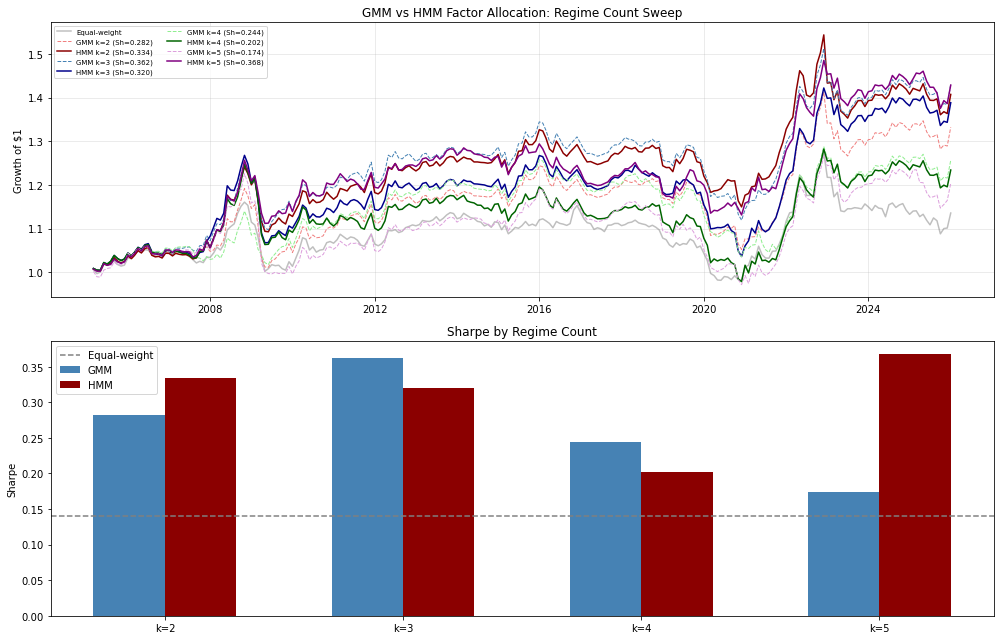

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

colors_gmm = {2:'lightcoral', 3:'steelblue', 4:'lightgreen', 5:'plum'}
colors_hmm = {2:'darkred', 3:'darkblue', 4:'darkgreen', 5:'purple'}

# Equity curves
eq_cum = np.cumprod(1 + sweep[0]['result']['eq_rets'])
axes[0].plot(sweep[0]['result']['dates'], eq_cum, 'gray', alpha=0.5, label='Equal-weight')

for s in sweep:
    name = s['model']
    k = int(name.split('=')[1])
    is_hmm = 'HMM' in name
    cum = np.cumprod(1 + s['result']['strat_rets'])
    color = colors_hmm[k] if is_hmm else colors_gmm[k]
    ls = '-' if is_hmm else '--'
    lw = 1.5 if is_hmm else 1.0
    axes[0].plot(s['result']['dates'], cum, color=color, ls=ls, lw=lw,
                  label=f'{name} (Sh={s["Sharpe"]:.3f})')

axes[0].set_title('GMM vs HMM Factor Allocation: Regime Count Sweep')
axes[0].set_ylabel('Growth of $1')
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

# Sharpe comparison bar chart
ks = [2, 3, 4, 5]
gmm_sharpes = [s['Sharpe'] for s in sweep if 'GMM' in s['model']]
hmm_sharpes = [s['Sharpe'] for s in sweep if 'HMM' in s['model']]
x = np.arange(len(ks))
axes[1].bar(x - 0.15, gmm_sharpes, 0.3, label='GMM', color='steelblue')
axes[1].bar(x + 0.15, hmm_sharpes, 0.3, label='HMM', color='darkred')
axes[1].axhline(y=compute_metrics(sweep[0]['result']['eq_rets'])['Sharpe'],
                 color='gray', ls='--', label='Equal-weight')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'k={k}' for k in ks])
axes[1].set_ylabel('Sharpe')
axes[1].set_title('Sharpe by Regime Count')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# HMM Deep Dive: Transition Matrices & Regime Dynamics
# ============================================================

# Run best HMM config for detailed analysis
best_k_hmm = max(
    [(s, s['Sharpe']) for s in sweep if 'HMM' in s['model']],
    key=lambda x: x[1]
)[0]
best_k = int(best_k_hmm['model'].split('=')[1])

print(f"Best HMM: k={best_k}, Sharpe={best_k_hmm['Sharpe']:.3f}")

r_hmm_best = best_k_hmm['result']

# Transition matrix
if r_hmm_best.get('trans_matrix') is not None:
    trans = r_hmm_best['trans_matrix']
    print(f"\nTransition matrix P[row -> col]:")
    for i in range(best_k):
        row = '  '.join(f'{trans[i,j]:.3f}' for j in range(best_k))
        print(f"  Regime {i}: [{row}]")

    print(f"\nExpected regime duration (months):")
    for i in range(best_k):
        dur = 1.0 / (1.0 - trans[i,i]) if trans[i,i] < 1 else float('inf')
        print(f"  Regime {i}: {dur:.1f} months")

    # Stationary distribution
    eigenvalues, eigenvectors = np.linalg.eig(trans.T)
    idx = np.argmin(np.abs(eigenvalues - 1.0))
    stationary = np.real(eigenvectors[:, idx])
    stationary = stationary / stationary.sum()
    print(f"\nStationary distribution:")
    for i in range(best_k):
        print(f"  Regime {i}: {stationary[i]:.1%}")

# Actual regime durations
regimes = r_hmm_best['regimes']
changes = np.diff(regimes) != 0
segments = np.cumsum(np.concatenate([[0], changes]))
seg_lengths = pd.Series(segments).groupby(pd.Series(segments)).count()

print(f"\nActual regime segment stats:")
print(f"  Mean duration: {seg_lengths.mean():.1f} months")
print(f"  Median: {seg_lengths.median():.1f} months")
print(f"  Max: {seg_lengths.max()} months")
print(f"  Regime changes: {changes.sum()} ({changes.mean():.1%} of months)")

# Compare with GMM turnover
best_gmm = [s for s in sweep if 'GMM' in s['model'] and f'k={best_k}' in s['model']][0]
print(f"\nTurnover comparison (k={best_k}):")
print(f"  GMM regime changes: {best_gmm['Changes']} ({best_gmm['Changes%']:.1%})")
print(f"  HMM regime changes: {best_k_hmm['Changes']} ({best_k_hmm['Changes%']:.1%})")

Best HMM: k=5, Sharpe=0.368

Transition matrix P[row -> col]:
  Regime 0: [0.000  0.000  0.009  0.000  0.991]
  Regime 1: [0.000  0.000  0.000  1.000  0.000]
  Regime 2: [0.003  0.250  0.500  0.000  0.247]
  Regime 3: [0.000  0.000  0.000  0.500  0.500]
  Regime 4: [0.850  0.000  0.000  0.000  0.150]

Expected regime duration (months):
  Regime 0: 1.0 months
  Regime 1: 1.0 months
  Regime 2: 2.0 months
  Regime 3: 2.0 months
  Regime 4: 1.2 months

Stationary distribution:
  Regime 0: 45.3%
  Regime 1: 0.2%
  Regime 2: 0.8%
  Regime 3: 0.4%
  Regime 4: 53.3%

Actual regime segment stats:
  Mean duration: 1.8 months
  Median: 1.0 months
  Max: 24 months
  Regime changes: 142 (56.8% of months)

Turnover comparison (k=5):
  GMM regime changes: 125 (49.8%)
  HMM regime changes: 142 (56.6%)


In [6]:
# ============================================================
# Per-regime factor performance (HMM vs GMM)
# ============================================================

print("=" * 80)
print(f"FACTOR PERFORMANCE BY REGIME (k={best_k})")
print("=" * 80)

for label, result in [('GMM', best_gmm['result']), ('HMM', r_hmm_best)]:
    print(f"\n--- {label} ---")
    regimes = result['regimes']
    dates = result['dates']
    
    factors_oos = factors_aligned.loc[pd.DatetimeIndex(dates)]
    
    for r in range(best_k):
        mask = regimes == r
        if mask.sum() < 3:
            continue
        r_factors = factors_oos[mask]
        avg = r_factors.mean() * 100
        
        best_f = avg.idxmax()
        worst_f = avg.idxmin()
        
        print(f"  Regime {r} ({mask.sum()} months): "
              f"Best={best_f} ({avg[best_f]:+.2f}%/mo), "
              f"Worst={worst_f} ({avg[worst_f]:+.2f}%/mo)")

FACTOR PERFORMANCE BY REGIME (k=5)

--- GMM ---
  Regime 0 (61 months): Best=RMW (+0.77%/mo), Worst=SMB (-0.26%/mo)
  Regime 1 (35 months): Best=RMW (+0.73%/mo), Worst=SMB (-0.18%/mo)
  Regime 2 (91 months): Best=HML (+0.76%/mo), Worst=Mom (-0.41%/mo)
  Regime 3 (37 months): Best=Mom (+0.41%/mo), Worst=HML (-0.36%/mo)
  Regime 4 (27 months): Best=Mom (+1.22%/mo), Worst=HML (-1.97%/mo)

--- HMM ---
  Regime 0 (51 months): Best=HML (+0.63%/mo), Worst=Mom (-0.22%/mo)
  Regime 1 (56 months): Best=RMW (+0.34%/mo), Worst=SMB (-0.79%/mo)
  Regime 2 (40 months): Best=Mom (+0.29%/mo), Worst=HML (-0.95%/mo)
  Regime 3 (46 months): Best=Mom (+0.92%/mo), Worst=HML (+0.05%/mo)
  Regime 4 (58 months): Best=RMW (+0.64%/mo), Worst=Mom (-0.34%/mo)


In [7]:
# ============================================================
# Final GMM vs HMM comparison
# ============================================================

print("=" * 80)
print("FINAL COMPARISON: GMM vs HMM FACTOR ALLOCATION")
print("=" * 80)

# Best of each
best_gmm_overall = max(
    [(s, s['Sharpe']) for s in sweep if 'GMM' in s['model']],
    key=lambda x: x[1]
)[0]
best_hmm_overall = max(
    [(s, s['Sharpe']) for s in sweep if 'HMM' in s['model']],
    key=lambda x: x[1]
)[0]
eq_sharpe = compute_metrics(sweep[0]['result']['eq_rets'])['Sharpe']

print(f"\n{'Metric':<25} {'GMM Best':>12} {'HMM Best':>12} {'Equal-Wt':>12}")
print("-" * 65)

for metric in ['Sharpe', 'Ann. Return', 'Max DD']:
    v_gmm = best_gmm_overall[metric]
    v_hmm = best_hmm_overall[metric]
    v_eq = compute_metrics(sweep[0]['result']['eq_rets'])[metric]
    if metric in ['Ann. Return', 'Max DD']:
        print(f"{metric:<25} {v_gmm:>11.1%} {v_hmm:>11.1%} {v_eq:>11.1%}")
    else:
        print(f"{metric:<25} {v_gmm:>12.3f} {v_hmm:>12.3f} {v_eq:>12.3f}")

print(f"{'Best k':<25} {best_gmm_overall['model']:>12} {best_hmm_overall['model']:>12}")
print(f"{'Regime changes':<25} {best_gmm_overall['Changes%']:>11.0%} {best_hmm_overall['Changes%']:>11.0%}")

winner = 'GMM' if best_gmm_overall['Sharpe'] > best_hmm_overall['Sharpe'] else 'HMM'
margin = abs(best_gmm_overall['Sharpe'] - best_hmm_overall['Sharpe'])
print(f"\nWinner: {winner} (by {margin:.3f} Sharpe)")

if best_hmm_overall['Changes%'] < best_gmm_overall['Changes%']:
    print(f"HMM has {best_gmm_overall['Changes%']-best_hmm_overall['Changes%']:.0%} fewer regime changes -> lower turnover")

FINAL COMPARISON: GMM vs HMM FACTOR ALLOCATION

Metric                        GMM Best     HMM Best     Equal-Wt
-----------------------------------------------------------------
Sharpe                           0.362        0.368        0.140
Ann. Return                      1.7%        1.7%        0.6%
Max DD                         -16.8%      -12.6%      -15.5%
Best k                         GMM k=3      HMM k=5
Regime changes                    18%         57%

Winner: HMM (by 0.006 Sharpe)


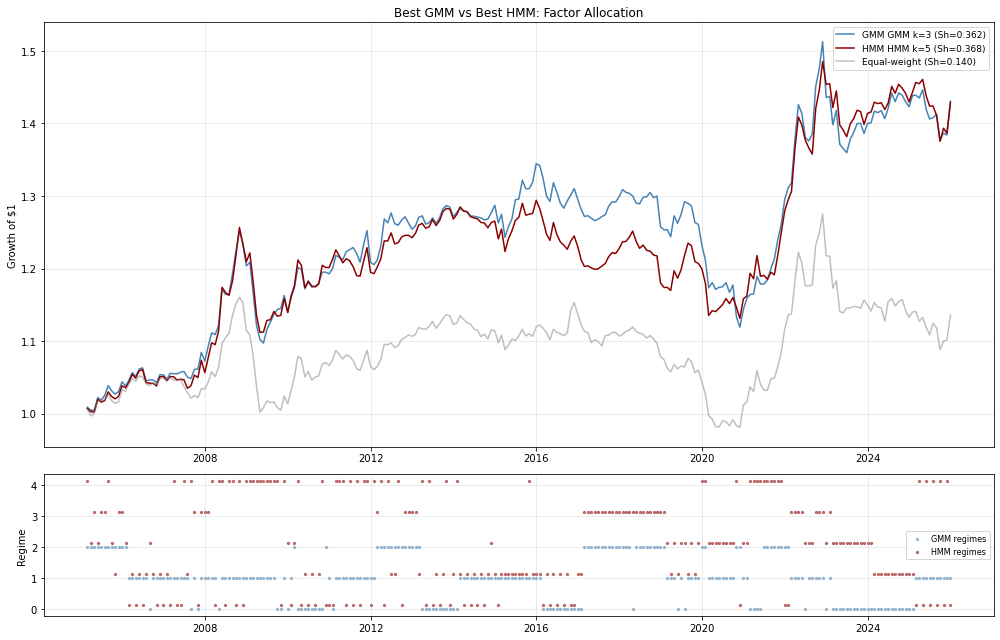

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})

gmm_cum = np.cumprod(1 + best_gmm_overall['result']['strat_rets'])
hmm_cum = np.cumprod(1 + best_hmm_overall['result']['strat_rets'])
eq_cum = np.cumprod(1 + best_gmm_overall['result']['eq_rets'])

axes[0].plot(best_gmm_overall['result']['dates'], gmm_cum,
              label=f'GMM {best_gmm_overall["model"]} (Sh={best_gmm_overall["Sharpe"]:.3f})',
              color='steelblue', linewidth=1.5)
axes[0].plot(best_hmm_overall['result']['dates'], hmm_cum,
              label=f'HMM {best_hmm_overall["model"]} (Sh={best_hmm_overall["Sharpe"]:.3f})',
              color='darkred', linewidth=1.5)
axes[0].plot(best_gmm_overall['result']['dates'], eq_cum,
              label=f'Equal-weight (Sh={eq_sharpe:.3f})',
              color='gray', alpha=0.5)
axes[0].set_title('Best GMM vs Best HMM: Factor Allocation')
axes[0].set_ylabel('Growth of $1')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Regime comparison
axes[1].scatter(best_gmm_overall['result']['dates'], best_gmm_overall['result']['regimes'],
                 s=5, alpha=0.5, color='steelblue', label='GMM regimes')
axes[1].scatter(best_hmm_overall['result']['dates'], 
                 best_hmm_overall['result']['regimes'] + 0.15,
                 s=5, alpha=0.5, color='darkred', label='HMM regimes')
axes[1].set_ylabel('Regime')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

**GMM vs HMM for factor allocation:**
- Same data (32 FRED-MD features), same allocation logic, different regime model
- HMM's advantage: transition persistence (fewer whipsaws, lower turnover)
- GMM's advantage: simpler, faster, proven in P3

**If HMM wins:** replace GMM in P3, benefit from more stable regime labels.
**If GMM wins:** HMM's transition modeling doesn't add value for monthly factor allocation — the regime persistence is already captured by the slow-moving macro features.
**If tie:** keep GMM (simpler), but note HMM as a valid alternative for applications where turnover matters more.